In [ ]:
!pip install entsoe-py

In [4]:
#Inputs for the dataset download, including DE split date
from entsoe import EntsoePandasClient
from entsoe.exceptions import NoMatchingDataError
import pandas as pd

client = EntsoePandasClient(api_key="5de489ac-9680-449e-a85d-3db36070c128")
start = pd.Timestamp('20160101', tz='UTC') #start date of the downloaded set
end = pd.Timestamp('20251231', tz='UTC') #end date of the downloaded set
geographies = ["DE_LU"]
country_mapping = {'ES': 'ES','FR': 'FR', 'DE_LU': 'DE_AT_LU'} #DE_LU price zone was DE_LU_AT before 2018
de_lu_at_split_date = pd.Timestamp("2018-10-01 00:00", tz="UTC")
def get_country_query_periods(country_code, startdate, enddate):
  if country_code != "DE_LU":
    return [(country_mapping.get(country_code, country_code), startdate, enddate)]

  if enddate <= de_lu_at_split_date:
    return [("DE_AT_LU", startdate, enddate)]

  if startdate >= de_lu_at_split_date:
    return [("DE_LU", startdate, enddate)]

  return [("DE_AT_LU", startdate, de_lu_at_split_date), ("DE_LU", de_lu_at_split_date, enddate)]
technologies = ["B16"] #Solar
technology_mapping = {'B16': 'Sol','B18': 'OSW','B19': 'ONW',} # Technology mapping for cleaner column names

In [42]:
import pandas as pd

# 0.0.0 Create function to convert to quarter-hourly UTC timestamp
def make_hourly(df, ts_col="timestamp"):
  df = df.copy()
  df[ts_col] = pd.to_datetime(df[ts_col], utc=True)

  # Set timestamp as index
  df = df.set_index(ts_col).sort_index()

  # Keep only numeric columns
  numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
  df = df[numeric_cols]

  # Convert all data to quarter-hourly frequency and forward fill unknowns
  df = df.resample("15min").ffill()
  df.index.name = ts_col
  return df

# 0.0.1 Create function to add "timestamp" to first column and set as index, then adjust to hourly
def add_timestamp(df):
  df = df.reset_index()
  df = df.rename(columns={"index": "timestamp"})
  df = make_hourly(df)
  return df

# 0.0.2 Helper to remove consumption columns from generation pulls
def remove_consumption_columns(df):
  cols_to_keep = []

  for col in df.columns:
    # Convert MultiIndex tuple to a single string for checking
    col_str_for_check = ' '.join([str(x) for x in col]) if isinstance(col, tuple) else str(col)

    if 'Consumption' not in col_str_for_check:
      cols_to_keep.append(col)

  return df[cols_to_keep]


# 0.0.3 Converts the output of a generation / forecast pull into one column named:
  #{country_code}_{data_type}_{mapped_technology_name}

def standardise_generation_columns(df, country_code, data_type, tech, remove_consumption=False):

  #Removes Consumption column
  if remove_consumption:
    df = remove_consumption_columns(df)

  #Changes the column names to standardised version (easier for analysis)
  mapped_tech_name = technology_mapping.get(tech, tech)
  cleaned_tech_name = mapped_tech_name.replace(' ', '_')
  target_col_name = f"{country_code}_{data_type}_{cleaned_tech_name}"

  if not df.empty and not df.columns.empty:
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if len(numeric_cols) > 0:
      aggregated_data = df[numeric_cols].sum(axis=1)
      df = pd.DataFrame({target_col_name: aggregated_data}, index=df.index)
    else:
      df = pd.DataFrame(columns=[target_col_name], index=df.index)
  else:
    df = pd.DataFrame(columns=[target_col_name], index=df.index)

  df.index.name = "timestamp"
  return df

# 0.1.0 - Actual generation
dfs_RES_ACT = []

def RES_actual(country_code, startdate, enddate, tech):

  try:
    df_parts = []

    for query_country_code, query_start, query_end in get_country_query_periods(country_code, startdate, enddate):
      df_part = client.query_generation(query_country_code, start=query_start, end=query_end, psr_type=tech)
      df_parts.append(df_part)

    df = pd.concat(df_parts)
    df = add_timestamp(df)

    df = standardise_generation_columns(df=df, country_code=country_code, data_type="ACT", tech=tech, remove_consumption=True)
    dfs_RES_ACT.append(df)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_ACT_{technology_mapping.get(tech, tech)}")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_RES_ACT.append(empty_df)

# 0.2.0 - Day-ahead prices
dfs_prices = []

def price_data(country_code, startdate, enddate):

  try:
    df_parts = []

    for query_country_code, query_start, query_end in get_country_query_periods(country_code, startdate, enddate):
      df_part = client.query_day_ahead_prices(query_country_code, start=query_start, end=query_end)
      df_parts.append(df_part)

    df_da = pd.concat(df_parts)
    df_da = add_timestamp(df_da)
    df_da = df_da.rename(columns={0: f"{country_code}_DA_price"})
    dfs_prices.append(df_da)

  except NoMatchingDataError:
    print(f"No data found for {country_code}_DA_price")
    empty_df = pd.DataFrame()
    empty_df.index.name = "timestamp"
    dfs_prices.append(empty_df)

# 1.0.0 Fetch the data for all technologies and all countries
for countries in geographies:
  for tech in technologies:
    RES_actual(countries, start, end, tech)
  price_data(countries, start, end)


# 1.0.1 Merge all dataframes along the timestamp column, and make timestamp index column
df = pd.concat(dfs_RES_ACT + dfs_prices, axis=1)
df = df.reset_index()
print(df.head(24))


                   timestamp  DE_LU_ACT_Sol  DE_LU_DA_price
0  2016-01-01 00:00:00+00:00           0.35           22.39
1  2016-01-01 00:15:00+00:00           0.35           22.39
2  2016-01-01 00:30:00+00:00           0.33           22.39
3  2016-01-01 00:45:00+00:00           0.31           22.39
4  2016-01-01 01:00:00+00:00           0.30           20.59
5  2016-01-01 01:15:00+00:00           0.29           20.59
6  2016-01-01 01:30:00+00:00           0.30           20.59
7  2016-01-01 01:45:00+00:00           0.32           20.59
8  2016-01-01 02:00:00+00:00           0.31           16.81
9  2016-01-01 02:15:00+00:00           0.31           16.81
10 2016-01-01 02:30:00+00:00           0.31           16.81
11 2016-01-01 02:45:00+00:00           0.30           16.81
12 2016-01-01 03:00:00+00:00           0.30           17.41
13 2016-01-01 03:15:00+00:00           0.30           17.41
14 2016-01-01 03:30:00+00:00           0.29           17.41
15 2016-01-01 03:45:00+00:00           0

**Optional Upload**

In [43]:
import os
from google.colab import drive
drive.mount('/content/drive')

save_folder = "/content/drive/MyDrive/Colab Notebooks/Green Baseload"
os.makedirs(save_folder, exist_ok=True)

csv_path = f"{save_folder}/entsoe_GBL_15min.csv"

df.to_csv(csv_path, index=False)

print(f"Saved CSV to: {csv_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved CSV to: /content/drive/MyDrive/Colab Notebooks/Green Baseload/entsoe_GBL_15min.csv


**Optional Download**

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

csv_path = "/content/drive/MyDrive/Colab Notebooks/Green Baseload/entsoe_GBL_15min.csv"

df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

print(df.head(24))

Mounted at /content/drive
                   timestamp  DE_LU_ACT_Sol  DE_LU_DA_price
0  2016-01-01 00:00:00+00:00           0.35           22.39
1  2016-01-01 00:15:00+00:00           0.35           22.39
2  2016-01-01 00:30:00+00:00           0.33           22.39
3  2016-01-01 00:45:00+00:00           0.31           22.39
4  2016-01-01 01:00:00+00:00           0.30           20.59
5  2016-01-01 01:15:00+00:00           0.29           20.59
6  2016-01-01 01:30:00+00:00           0.30           20.59
7  2016-01-01 01:45:00+00:00           0.32           20.59
8  2016-01-01 02:00:00+00:00           0.31           16.81
9  2016-01-01 02:15:00+00:00           0.31           16.81
10 2016-01-01 02:30:00+00:00           0.31           16.81
11 2016-01-01 02:45:00+00:00           0.30           16.81
12 2016-01-01 03:00:00+00:00           0.30           17.41
13 2016-01-01 03:15:00+00:00           0.30           17.41
14 2016-01-01 03:30:00+00:00           0.29           17.41
15 2016-01-01 

**Normalisation of generation values**

In [6]:
# 2.0.0 Import numpy
import numpy as np

#2.0.1 Add columns for year, month, day and hour of timestamp
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
summary_rows = []

#2.1.0 For each country and technology, normalise the production against the max production in that year
for country_code in geographies:
  for tech in technologies:

    mapped_tech_name = technology_mapping.get(tech, tech)
    cleaned_tech_name = mapped_tech_name.replace(' ', '_')
    act_col = f"{country_code}_ACT_{cleaned_tech_name}"
    norm_act_col = f"{country_code}_NORM_ACT_{cleaned_tech_name}"
    da_price_col = f"{country_code}_DA_price"

    #Normalisation function
    years = df['year'].unique()
    for year in years:
      year_df = df[df['year'] == year]
      max_generation = year_df[act_col].max()
      #Divide yearly solar production by the max generation in year to normalise
      if pd.notna(max_generation) and max_generation != 0:
        df[norm_act_col] = df[act_col] / max_generation
      else:
        df[norm_act_col] = np.nan

print(df.head(50))

                   timestamp  DE_LU_ACT_Sol  DE_LU_DA_price  year  month  day  \
0  2016-01-01 00:00:00+00:00           0.35           22.39  2016      1    1   
1  2016-01-01 00:15:00+00:00           0.35           22.39  2016      1    1   
2  2016-01-01 00:30:00+00:00           0.33           22.39  2016      1    1   
3  2016-01-01 00:45:00+00:00           0.31           22.39  2016      1    1   
4  2016-01-01 01:00:00+00:00           0.30           20.59  2016      1    1   
5  2016-01-01 01:15:00+00:00           0.29           20.59  2016      1    1   
6  2016-01-01 01:30:00+00:00           0.30           20.59  2016      1    1   
7  2016-01-01 01:45:00+00:00           0.32           20.59  2016      1    1   
8  2016-01-01 02:00:00+00:00           0.31           16.81  2016      1    1   
9  2016-01-01 02:15:00+00:00           0.31           16.81  2016      1    1   
10 2016-01-01 02:30:00+00:00           0.31           16.81  2016      1    1   
11 2016-01-01 02:45:00+00:00

**Baseload PPA calculations**

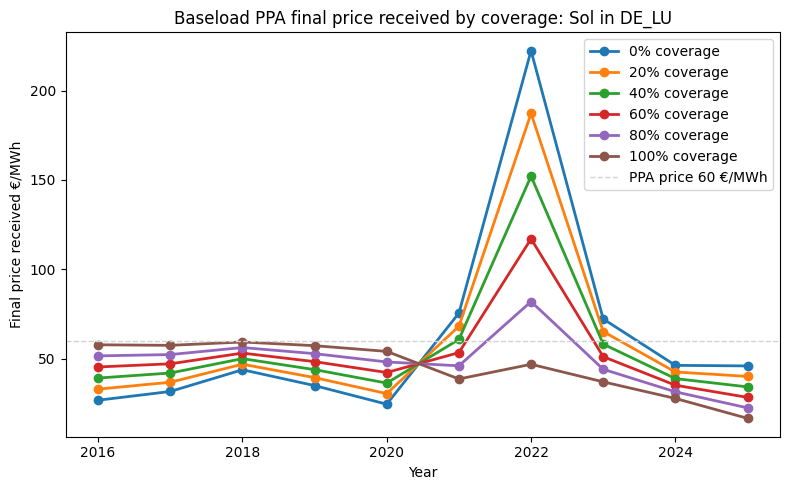

                                       scenario   2016   2017   2018   2019  \
0                                     PPA price   60.0   60.0   60.0   60.0   
1               0% coverage - final price €/MWh   26.7   31.6   43.8   34.9   
2     0% coverage - discount to PPA price €/MWh  -33.3  -28.4  -16.2  -25.1   
3              20% coverage - final price €/MWh   32.9   36.8   46.9   39.4   
4    20% coverage - discount to PPA price €/MWh  -27.1  -23.2  -13.1  -20.6   
5              40% coverage - final price €/MWh   39.1   41.9   50.0   43.8   
6    40% coverage - discount to PPA price €/MWh  -20.9  -18.1  -10.0  -16.2   
7              60% coverage - final price €/MWh   45.3   47.1   53.1   48.3   
8    60% coverage - discount to PPA price €/MWh  -14.7  -12.9   -6.9  -11.7   
9              80% coverage - final price €/MWh   51.5   52.3   56.2   52.8   
10   80% coverage - discount to PPA price €/MWh   -8.5   -7.7   -3.8   -7.2   
11            100% coverage - final price €/MWh   57

In [26]:
import numpy as np
import pandas as pd

#3.0.0 Begin simulating the baseload PPA
def simulate_baseload_ppa(df, country_code, tech, year, coverage, price, asset_capacity, target_yield_hours):
  mapped_tech_name = technology_mapping.get(tech, tech)
  cleaned_tech_name = mapped_tech_name.replace(' ', '_')
  norm_act_col = f"{country_code}_NORM_ACT_{cleaned_tech_name}"
  da_price_col = f"{country_code}_DA_price"
  asset_col = f"{country_code}_assetMW_{cleaned_tech_name}"
  ppa_col = f"{country_code}_ppaMW_{cleaned_tech_name}"
  surplus_col = f"{country_code}_surplus_{cleaned_tech_name}"
  shortfall_col = f"{country_code}_shortfall_{cleaned_tech_name}"

  year_df = df[df['year'] == year].copy()
  year_df[asset_col] = year_df[norm_act_col] * asset_capacity

  hours_in_year = len(year_df) / 4
  raw_asset_generation_MWh = year_df[asset_col].sum() / 4
  target_asset_generation_MWh = asset_capacity * target_yield_hours
  yield_scaling_factor = target_asset_generation_MWh / raw_asset_generation_MWh if raw_asset_generation_MWh != 0 else np.nan

  year_df[asset_col] = year_df[asset_col] * yield_scaling_factor

  asset_generation_MWh = year_df[asset_col].sum() / 4
  asset_yield_hours = asset_generation_MWh / asset_capacity
  solar_capture_value_EUR = (year_df[asset_col] * year_df[da_price_col] / 4).sum()
  solar_capture_price_EUR_MWh = solar_capture_value_EUR / asset_generation_MWh if asset_generation_MWh != 0 else np.nan

  contracted_volume_MWh = coverage * asset_generation_MWh
  ppa_MW = contracted_volume_MWh / hours_in_year

  year_df[ppa_col] = ppa_MW
  year_df[surplus_col] = np.where(year_df[asset_col] > year_df[ppa_col], year_df[asset_col] - year_df[ppa_col], 0)
  year_df[shortfall_col] = np.where(year_df[asset_col] < year_df[ppa_col], year_df[asset_col] - year_df[ppa_col], 0)

  merchant_surplus_volume_MWh = year_df[surplus_col].sum() / 4
  merchant_shortfall_volume_MWh = -year_df[shortfall_col].sum() / 4

  contracted_value_EUR = contracted_volume_MWh * price
  merchant_surplus_value_EUR = (year_df[surplus_col] * year_df[da_price_col] / 4).sum()
  merchant_shortfall_value_EUR = (year_df[shortfall_col] * year_df[da_price_col] / 4).sum()
  final_value_EUR = contracted_value_EUR + merchant_surplus_value_EUR + merchant_shortfall_value_EUR

  contracted_price_EUR_MWh = contracted_value_EUR / contracted_volume_MWh if contracted_volume_MWh != 0 else np.nan
  merchant_surplus_price_EUR_MWh = merchant_surplus_value_EUR / merchant_surplus_volume_MWh if merchant_surplus_volume_MWh != 0 else np.nan
  merchant_shortfall_price_EUR_MWh = merchant_shortfall_value_EUR / merchant_shortfall_volume_MWh if merchant_shortfall_volume_MWh != 0 else np.nan
  final_price_EUR_MWh = final_value_EUR / asset_generation_MWh if asset_generation_MWh != 0 else np.nan
  final_price_rebased_to_capture_EUR_MWh = final_price_EUR_MWh - solar_capture_price_EUR_MWh

  output_df = pd.DataFrame([
    {"country": country_code, "technology": cleaned_tech_name, "year": year, "line_item": "Contracted PPA", "value_EUR": contracted_value_EUR, "volume_MWh": contracted_volume_MWh, "price_EUR_MWh": contracted_price_EUR_MWh},
    {"country": country_code, "technology": cleaned_tech_name, "year": year, "line_item": "Merchant surplus", "value_EUR": merchant_surplus_value_EUR, "volume_MWh": merchant_surplus_volume_MWh, "price_EUR_MWh": merchant_surplus_price_EUR_MWh},
    {"country": country_code, "technology": cleaned_tech_name, "year": year, "line_item": "Merchant shortfall", "value_EUR": merchant_shortfall_value_EUR, "volume_MWh": merchant_shortfall_volume_MWh, "price_EUR_MWh": merchant_shortfall_price_EUR_MWh},
    {"country": country_code, "technology": cleaned_tech_name, "year": year, "line_item": "Final", "value_EUR": final_value_EUR, "volume_MWh": asset_generation_MWh, "price_EUR_MWh": final_price_EUR_MWh}
  ])

  output_df["solar_capture_price_EUR_MWh"] = solar_capture_price_EUR_MWh
  output_df["price_rebased_to_capture_EUR_MWh"] = output_df["price_EUR_MWh"] - output_df["solar_capture_price_EUR_MWh"]

  output_df["asset_capacity_MW"] = asset_capacity
  output_df["coverage"] = coverage
  output_df["actual_asset_yield_hours"] = asset_yield_hours
  output_df["target_yield_hours"] = target_yield_hours
  output_df["ppa_MW"] = ppa_MW

  return output_df

#3.0.1 Run the simulation for each year and print outputs
asset_capacity = 100
price = 60
coverage_cases = [0, 0.2, 0.4, 0.6, 0.8, 1]
target_yield_hours = 1200
ppa_outputs = []

for country_code in geographies:
  for tech in technologies:
    for year in sorted(df['year'].unique()):
      for coverage in coverage_cases:
        result_df = simulate_baseload_ppa(df, country_code, tech, year, coverage, price, asset_capacity, target_yield_hours)
        ppa_outputs.append(result_df)

ppa_results_df = pd.concat(ppa_outputs, ignore_index=True)
#ppa_results_display = ppa_results_df.copy()
#ppa_results_display["value_EUR"] = ppa_results_display["value_EUR"].map(lambda x: f"{x:,.0f}")
#ppa_results_display["volume_MWh"] = ppa_results_display["volume_MWh"].map(lambda x: f"{x:,.0f}")
#ppa_results_display["price_EUR_MWh"] = ppa_results_display["price_EUR_MWh"].map(lambda x: f"{x:,.2f}")
#ppa_results_display["actual_asset_yield_hours"] = ppa_results_display["actual_asset_yield_hours"].map(lambda x: f"{x:,.0f}")
#ppa_results_display["ppa_MW"] = ppa_results_display["ppa_MW"].map(lambda x: f"{x:,.1f}")

#print(ppa_results_display)

#3.0.2 Chart final price received by coverage
import matplotlib.pyplot as plt

final_df = ppa_results_df[ppa_results_df["line_item"] == "Final"].copy()

for country_code in geographies:
  for tech in technologies:
    mapped_tech_name = technology_mapping.get(tech, tech)
    cleaned_tech_name = mapped_tech_name.replace(' ', '_')
    plot_df = final_df[(final_df["country"] == country_code) & (final_df["technology"] == cleaned_tech_name)].copy()

    if plot_df.empty:
      print(f"No final PPA results for {country_code}, {cleaned_tech_name}")
      continue

    plt.figure(figsize=(8, 5))

    for coverage in coverage_cases:
      coverage_df = plot_df[plot_df["coverage"] == coverage].sort_values("year")
      if coverage_df.empty:
        continue
      plt.plot(coverage_df["year"], coverage_df["price_EUR_MWh"], marker="o", linewidth=2, label=f"{coverage:.0%} coverage")

    plt.axhline(price, color="lightgrey", linewidth=1, linestyle="--", label=f"PPA price {price} €/MWh")
    plt.xlabel("Year")
    plt.ylabel("Final price received €/MWh")
    plt.title(f"Baseload PPA final price received by coverage: {cleaned_tech_name} in {country_code}")
    plt.legend()
    plt.tight_layout()
    plt.show()

#3.0.3 Create write-up table: final price and discount to PPA price by coverage

final_df = ppa_results_df[ppa_results_df["line_item"] == "Final"].copy()

writeup_rows = []

# Add PPA price reference row
ppa_price_row = {"scenario": "PPA price"}
for year in sorted(final_df["year"].unique()):
  ppa_price_row[year] = price
writeup_rows.append(ppa_price_row)

# Add final price and discount rows for each coverage case
for coverage in coverage_cases:
  coverage_df = final_df[final_df["coverage"] == coverage].copy()

  final_price_row = {"scenario": f"{coverage:.0%} coverage - final price €/MWh"}
  discount_row = {"scenario": f"{coverage:.0%} coverage - discount to PPA price €/MWh"}

  for year in sorted(final_df["year"].unique()):
    year_match = coverage_df[coverage_df["year"] == year]

    if year_match.empty:
      final_price_row[year] = np.nan
      discount_row[year] = np.nan
    else:
      final_price = year_match["price_EUR_MWh"].iloc[0]
      final_price_row[year] = final_price
      discount_row[year] = final_price - price

  writeup_rows.append(final_price_row)
  writeup_rows.append(discount_row)

ppa_writeup_table = pd.DataFrame(writeup_rows)

# Format for write-up display
ppa_writeup_table_display = ppa_writeup_table.copy()
year_cols = [col for col in ppa_writeup_table_display.columns if col != "scenario"]

for col in year_cols:
  ppa_writeup_table_display[col] = ppa_writeup_table_display[col].map(lambda x: "" if pd.isna(x) else f"{x:.1f}")

print(ppa_writeup_table_display)


In [27]:
# 3.0.3 Build 30-year contracted / merchant cashflow scenarios

import numpy as np
import pandas as pd

def build_ppa_lifetime_cashflows(ppa_results_df, start_year, project_life_years=30, contracted_discount_rate=0.06, merchant_discount_rate=0.09):
  final_observed_year = int(ppa_results_df["year"].max())
  first_observed_year = int(ppa_results_df["year"].min())
  end_year = start_year + project_life_years - 1

  if start_year < first_observed_year or start_year > final_observed_year:
    raise ValueError(f"start_year must be between {first_observed_year} and {final_observed_year}")

  scenario_cols = ["country", "technology", "coverage", "asset_capacity_MW", "target_yield_hours"]

  contracted_df = ppa_results_df[ppa_results_df["line_item"] == "Contracted PPA"].copy()
  merchant_df = ppa_results_df[ppa_results_df["line_item"].isin(["Merchant surplus", "Merchant shortfall"])].copy()

  contracted_annual = contracted_df.groupby(scenario_cols + ["year"], as_index=False)["value_EUR"].sum().rename(columns={"value_EUR": "contracted_cashflow_EUR"})
  merchant_annual = merchant_df.groupby(scenario_cols + ["year"], as_index=False)["value_EUR"].sum().rename(columns={"value_EUR": "merchant_cashflow_EUR"})

  annual_cf = pd.merge(contracted_annual, merchant_annual, on=scenario_cols + ["year"], how="outer").fillna(0)
  annual_cf = annual_cf[(annual_cf["year"] >= start_year) & (annual_cf["year"] <= final_observed_year)].copy()

  extension_rows = []

  for scenario_key, scenario_df in annual_cf.groupby(scenario_cols):
    scenario_dict = dict(zip(scenario_cols, scenario_key))
    final_year_row = scenario_df[scenario_df["year"] == final_observed_year]

    if final_year_row.empty:
      continue

    final_contracted_cashflow = final_year_row["contracted_cashflow_EUR"].iloc[0]
    final_merchant_cashflow = final_year_row["merchant_cashflow_EUR"].iloc[0]

    for year in range(final_observed_year + 1, end_year + 1):
      extension_rows.append({
        **scenario_dict,
        "year": year,
        "contracted_cashflow_EUR": final_contracted_cashflow,
        "merchant_cashflow_EUR": final_merchant_cashflow
      })

  extension_df = pd.DataFrame(extension_rows)

  if not extension_df.empty:
    annual_cf = pd.concat([annual_cf, extension_df], ignore_index=True)

  annual_cf = annual_cf.sort_values(scenario_cols + ["year"]).reset_index(drop=True)
  annual_cf["project_year"] = annual_cf["year"] - start_year
  annual_cf["contracted_discount_factor"] = 1 / ((1 + contracted_discount_rate) ** annual_cf["project_year"])
  annual_cf["merchant_discount_factor"] = 1 / ((1 + merchant_discount_rate) ** annual_cf["project_year"])

  annual_cf["contracted_PV_EUR"] = annual_cf["contracted_cashflow_EUR"] * annual_cf["contracted_discount_factor"]
  annual_cf["merchant_PV_EUR"] = annual_cf["merchant_cashflow_EUR"] * annual_cf["merchant_discount_factor"]
  annual_cf["total_cashflow_EUR"] = annual_cf["contracted_cashflow_EUR"] + annual_cf["merchant_cashflow_EUR"]
  annual_cf["total_PV_EUR"] = annual_cf["contracted_PV_EUR"] + annual_cf["merchant_PV_EUR"]

  summary_df = annual_cf.groupby(scenario_cols, as_index=False).agg(
    contracted_NPV_EUR=("contracted_PV_EUR", "sum"),
    merchant_NPV_EUR=("merchant_PV_EUR", "sum"),
    total_NPV_EUR=("total_PV_EUR", "sum"),
    undiscounted_contracted_EUR=("contracted_cashflow_EUR", "sum"),
    undiscounted_merchant_EUR=("merchant_cashflow_EUR", "sum"),
    undiscounted_total_EUR=("total_cashflow_EUR", "sum")
  )

  return annual_cf, summary_df

investment_year = 2016

ppa_lifetime_cf_df, ppa_lifetime_summary_df = build_ppa_lifetime_cashflows(
  ppa_results_df=ppa_results_df,
  start_year=investment_year,
  project_life_years=30,
  contracted_discount_rate=0.06,
  merchant_discount_rate=0.09
)

#print(ppa_lifetime_cf_df.head(40))
print(ppa_lifetime_summary_df)

  country technology  coverage  asset_capacity_MW  target_yield_hours  \
0   DE_LU        Sol       0.0                100                1200   
1   DE_LU        Sol       0.2                100                1200   
2   DE_LU        Sol       0.4                100                1200   
3   DE_LU        Sol       0.6                100                1200   
4   DE_LU        Sol       0.8                100                1200   
5   DE_LU        Sol       1.0                100                1200   

   contracted_NPV_EUR  merchant_NPV_EUR  total_NPV_EUR  \
0        0.000000e+00      7.143382e+07   7.143382e+07   
1        2.101064e+07      5.079724e+07   7.180788e+07   
2        4.202128e+07      3.016066e+07   7.218194e+07   
3        6.303191e+07      9.524084e+06   7.255600e+07   
4        8.404255e+07     -1.111249e+07   7.293006e+07   
5        1.050532e+08     -3.174907e+07   7.330412e+07   

   undiscounted_contracted_EUR  undiscounted_merchant_EUR  \
0                   